In [186]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from sim import *
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import tensorflow
from tensorflow.keras.models import load_model
from keras import metrics
import joblib
import toy_functions as f

plt.rcParams.update({"text.usetex": True, "font.family": "serif"})

In [176]:
GRIDSIZE = 30
LOG_SIN2_2THETA_BOUNDS = (-4., 0.)
LOG_DELTA_M2_BOUNDS = (0., 3.)
log_sin2_2theta_grid = np.linspace(*LOG_SIN2_2THETA_BOUNDS, GRIDSIZE)
log_delta_m2_grid = np.linspace(*LOG_DELTA_M2_BOUNDS, GRIDSIZE)
THETAS = np.array([[logsinsq, logdmsq] for logsinsq in log_sin2_2theta_grid for logdmsq in log_delta_m2_grid])

# PG Tension using Exact Chi2

The Maltoni-Schwetz prescription of PG tension is a difference in minimum likelihoods between $r$ independent datasets
$$
\chi^2_{PG} = \chi^2_{glob}  - \sum_r \chi^2_r. 
$$

Here we consider two experiments, Exp A and Exp B, that have the exact same statistical and systematic error. Thus we can use the same simulator (`sim.py`) to generate results for both. To compute the PG tension empirically, we

1. Simulate many pseudo-experiments from null for both experiments
2. For Exp A and Exp B, compute an exact $\Delta \chi^2$ assuming a Poisson process for all points on the parameter space grid. Compute $\Delta \chi^2_{comb} = \Delta \chi^2_A + \Delta \chi^2_B$ for the null experiments. 
3. Find $\min_\theta \Delta \chi^2_A$, $\min_\theta \Delta \chi^2_B$, and $\min_\theta \Delta \chi^2_{comb}$, and evaluate $\chi^2_{PG} = \min_\theta \Delta \chi^2_{comb} - \min_\theta \Delta \chi^2_B - \min_\theta \Delta \chi^2_A$.
4. Simulate pseudo-experiments from a point in signal space for Exp A, and null space for Exp B. 
5. Repeat Steps 2-3 for the "tense" pseudo-experiments

In [2]:
## NULL PSEUDO-EXPERIMENT GENERATION

#exp1
x_arr_null1 = []
for i in range(0,5000):
    counts, expected_signal = simulate_counts(
        sin2_2theta=0,
        delta_m2=0
    )
    x_arr_null1.append(counts)

#exp2
x_arr_null2 = []
for i in range(0,5000):
    counts, expected_signal = simulate_counts(
        sin2_2theta=0,
        delta_m2=0
    )
    x_arr_null2.append(counts)
    
#combined
x_arr_null = np.c_[x_arr_null1, x_arr_null2]

In [28]:
## "TENSE" PSEUDO-EXPERIMENT GENERATION

data_arr = []
for i in range(0,100):
    data1, _ = simulate_counts(
        sin2_2theta=0.1,
        delta_m2=4
    )

    data2, _ = simulate_counts(
        sin2_2theta=0.001,
        delta_m2=0
    )

    data = np.concatenate((data1, data2))
    data_arr.append(data)

In [152]:
#adding realizations generated from a point slightly farther in signal-space
data_arr2 = []
for i in range(0,30):
    data1, _ = simulate_counts(
        sin2_2theta=0.1,
        delta_m2=6
    )

    data2, _ = simulate_counts(
        sin2_2theta=0.001,
        delta_m2=0.01
    )

    data = np.concatenate((data1, data2))
    data_arr2.append(data)

In [49]:
#constructing empirical distribution
PG_null_exact = []
for data in tqdm(x_arr_null):
    data1=data[:5]
    data2 = data[5:]
    chi2_1 = np.array([
    f.compute_delta_chi2(data1, 10**theta[0], 10**theta[1])
    for theta in THETAS
    ])
    chi2_2 = np.array([
    f.compute_delta_chi2(data2, 10**theta[0], 10**theta[1])
    for theta in THETAS
    ])
    
    chi2_1_min = np.min(chi2_1)
    chi2_2_min = np.min(chi2_2)
    joint_chi2 = chi2_1 + chi2_2
    joint_chi2_min = np.min(joint_chi2)
    PG = joint_chi2_min - chi2_1_min - chi2_2_min
    PG_null_exact.append(PG)
    
np.save("../toy/output/PG_null_exact", PG_null_exact)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [51:24<00:00,  1.62it/s]


It is a common practice to approximate $\chi^2_{PG}$ as a $\chi^2$ distribution with $P_{glob} - \sum_r P_r$ degrees of freedom, with $P_{glob}$ being the number of fitted parameters in the combined fit, and $P_r$ the number of fitted parameters in the single-experiment fits. In many cases, this is a valid approximation, and particularly useful to avoid the expensive evaluation of a large number of trials. 

In this particular toy example, we notice that the distribution of $\chi^2_{PG}$ for null pseudo-experiments does not completely follow a $\chi^2$ with 2 degrees of freedom ($P_{glob} = P_{A} = P_B = 2$) (see below), and so we instead use the empirical distribution to calculate the significance of $\chi^2_PG$ for our tense pseudo-experiments.

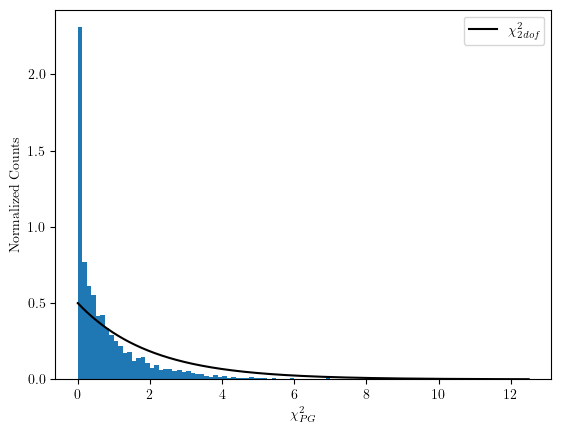

In [187]:
plt.hist(PG_null_exact, bins = 100, density = True)
x = np.linspace(0, max(PG_null_exact), 500)
y = stats.chi2.pdf(x, df=2)
plt.plot(x,y, color = 'black', label = '$\chi^2_{2 dof}$')
plt.xlabel("$\chi^2_{PG}$")
plt.legend()
plt.ylabel("Normalized Counts")
plt.show()

In [34]:
log_p_vals_exact_freq = []
for data in tqdm(data_arr):
    data1=data[:5]
    data2 = data[5:]
    chi2_1 = np.array([
    f.compute_delta_chi2(data1, 10**theta[0], 10**theta[1])
    for theta in THETAS
    ])
    chi2_2 = np.array([
    f.compute_delta_chi2(data2, 10**theta[0], 10**theta[1])
    for theta in THETAS
    ])
    
    chi2_1_min = np.min(chi2_1)
    chi2_2_min = np.min(chi2_2)
    joint_chi2 = chi2_1 + chi2_2
    joint_chi2_min = np.min(joint_chi2)
    PG = joint_chi2_min - chi2_1_min - chi2_2_min
    p_val =np.mean(PG_null_exact>PG)
    log_p_vals_exact_freq.append(-np.log(p_val))
    

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:04<00:00,  1.54it/s]


In [154]:
for data in tqdm(data_arr2):
    data1=data[:5]
    data2 = data[5:]
    chi2_1 = np.array([
    f.compute_delta_chi2(data1, 10**theta[0], 10**theta[1])
    for theta in THETAS
    ])
    chi2_2 = np.array([
    f.compute_delta_chi2(data2, 10**theta[0], 10**theta[1])
    for theta in THETAS
    ])
    
    chi2_1_min = np.min(chi2_1)
    chi2_2_min = np.min(chi2_2)
    joint_chi2 = chi2_1 + chi2_2
    joint_chi2_min = np.min(joint_chi2)
    PG = joint_chi2_min - chi2_1_min - chi2_2_min
    p_val =np.mean(PG_null_exact>PG)
    log_p_vals_exact_freq.append(-np.log(p_val))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:38<00:00,  1.31it/s]


# PG Tension using SBI

To evaluate tension using SBI, we find $\chi^2_{PG}$ using a difference in $\Delta \chi^2$s:

$$\chi^2_{PG} = \chi^2_{glob,min} - \chi^2_{A,min} - \chi^2_{B,min}$$
$$= \chi^2_{glob,min} - \chi^2_{A,min} - \chi^2_{B,min} - (\chi^2_{glob,0} - \chi^2_{A,0} - \chi^2_{B,0})$$
$$=\Delta \chi^2_{glob} - \Delta \chi^2_{A} - \Delta \chi^2_B.$$
We have access to log-likelihood ratios $\hat r(x, \theta_1, \theta_2)$ via our network, thus we can construct an SBI-analogue of the PG statistic, $\hat T_{PG}$:
$$T(\theta) = -2 \hat r(x, \theta_0, \hat \theta)_{comb} - (-2 \hat r(x, \theta_0, \hat \theta)_A) - (-2 \hat r(x, \theta_0, \hat \theta)_B)$$

and we calculate this significance of $T_{PG}$ for tense pseudo-experiments empirically, using a distribution of $T_{PG}$ evaluated on null pseudo-experiments.

In [3]:
#loading in model trained on combined data
model_comb = load_model('../toy/models/model_comb.keras')
pre_sigmoid_model_comb= load_model("../toy/models/pre_sig_model_comb.keras", compile=False)
optimizer = tensorflow.keras.optimizers.Adam(learning_rate=1e-4)
pre_sigmoid_model_comb.compile(optimizer=optimizer, loss='binary_crossentropy',metrics=[metrics.AUC()])
scaler_comb = joblib.load("../toy/models/scaler_comb.joblib")

#same model for experiment A and B
model = load_model('../toy/models/model.keras')
pre_sigmoid_model= load_model("../toy/models/pre_sig_model.keras", compile=False)
optimizer = tensorflow.keras.optimizers.Adam(learning_rate=1e-4)
pre_sigmoid_model.compile(optimizer=optimizer, loss='binary_crossentropy',metrics=[metrics.AUC()])
scaler = joblib.load("../toy/models/scaler.joblib")

In [9]:
#picking a null parameter point to evaluate the log-likelihood ratio with
th_null = np.array([-3.9,0.5])

#constructing null distribution of \hat r(x, \theta_0, \hat \theta)_{comb}
dllh_null_sbi = []
bfs_null = []
for x in tqdm(x_arr_null):
    llh,bfp = f.compute_dllh_estimate(th_null, x, pre_sigmoid_model_comb, scaler_comb, 300, GRIDSIZE)
    dllh_null_sbi.append(llh)
    bfs_null.append(bfp)
    
np.save("../toy/output/dllh_null_comb", np.array(dllh_null_sbi))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [26:51<00:00,  3.10it/s]


In [11]:
#constructing null distribution of \hat r(x, \theta_0, \hat \theta)_{A}
dllh_null_sbi1 = []
bfs_null1 = []
for x in tqdm(x_arr_null):
    llh,bfp = f.compute_dllh_estimate(th_null, x[:5], pre_sigmoid_model, scaler, 300, GRIDSIZE)
    dllh_null_sbi1.append(llh)
    bfs_null1.append(bfp)
    
np.save("../toy/output/dllh_null1", np.array(dllh_null_sbi1))

 76%|███████████████████████████████████████████████████████████████████▊                     | 3807/5000 [18:16<05:42,  3.48it/s]

In [12]:
#constructing null distribution of \hat r(x, \theta_0, \hat \theta)_{B}
dllh_null_sbi2 = []
bfs_null2 = []
for x in tqdm(x_arr_null):
    llh,bfp = f.compute_dllh_estimate(th_null, x[5:], pre_sigmoid_model, scaler, 300, GRIDSIZE)
    dllh_null_sbi2.append(llh)
    bfs_null2.append(bfp)

np.save("../toy/output/dllh_null2", np.array(dllh_null_sbi2))

In [30]:
dllh_PG_null =np.array(dllh_null_sbi) - np.array(dllh_null_sbi1) - np.array(dllh_null_sbi2)

#evaluating tense realizations using SBI
log_p_vals = []
for data in tqdm(data_arr):
    dllh1, bfp = f.compute_dllh_estimate(th_null, data[:5], pre_sigmoid_model, scaler, 500, GRIDSIZE)
    dllh2, bfp = f.compute_dllh_estimate(th_null, data[5:], pre_sigmoid_model, scaler, 500, GRIDSIZE)
    dllh_comb, bfp = f.compute_dllh_estimate(th_null, data, pre_sigmoid_model_comb, scaler_comb, 500, GRIDSIZE)

    dllh_PG = dllh_comb - dllh1 - dllh2
    p_val = np.mean(dllh_PG_null>dllh_PG)
    log_p_vals.append(-np.log(p_val))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:14<00:00,  1.34s/it]


In [153]:
for data in tqdm(data_arr2):
    dllh1, bfp = f.compute_dllh_estimate(th_null, data[:5], pre_sigmoid_model, scaler, 500, GRIDSIZE)
    dllh2, bfp = f.compute_dllh_estimate(th_null, data[5:], pre_sigmoid_model, scaler, 500, GRIDSIZE)
    dllh_comb, bfp = f.compute_dllh_estimate(th_null, data, pre_sigmoid_model_comb, scaler_comb, 500, GRIDSIZE)
    dllh1_sig.append(dllh1)
    dllh2_sig.append(dllh2)
    dllh_comb_sig.append(dllh_comb)
    dllh_PG = dllh_comb - dllh1 - dllh2
    p_val = np.mean(dllh_PG_null>dllh_PG)
    log_p_vals.append(-np.log(p_val))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:06<00:00,  1.33s/it]


Below, we compare empirically-computed $p$-values for $\hat T_{PG}$ (SBI) and $\chi^2_{PG}$ (exact). Since the $p$-value is computed empirically, there is some statistical uncertainty associated with the measurement, dependent on the number of samples $N$ in the distribution: 
$$\sigma_p = \sqrt{\frac{p(1-p)}{N}}$$

We plot the negative log of the $p$-values for both methods with the horizontal and vertical error bars indicating the statistical uncertainty. 

In [173]:
def uncert(log_p):
    sigma = np.sqrt(np.exp(log_p)*(1-np.exp(log_p))/5000)
    lerr = -np.log(np.exp(log_p)+sigma)
    uerr = -np.log(np.exp(log_p)-sigma)
    return lerr, uerr

err = []
for log_p in log_p_vals_exact_freq:
    lerr, uerr = uncert(-log_p)
    err.append([lerr, uerr])
    
err = np.array(err)
low_err = log_p_vals_exact_freq - err[:,0]
upp_err = err[:,1] - log_p_vals_exact_freq

err = []
for log_p in log_p_vals:
    lerr, uerr = uncert(-log_p)
    err.append([lerr, uerr])
    
err = np.array(err)
low_erry = log_p_vals - err[:,0]
upp_erry = err[:,1] - log_p_vals


In [185]:
np.save("../toy/output/log_p_vals", log_p_vals)
np.save("../toy/output/log_p_vals_exact_freq", log_p_vals_exact_freq)

Text(0, 0.5, '$-\\log p_{val}$ (SBI)')

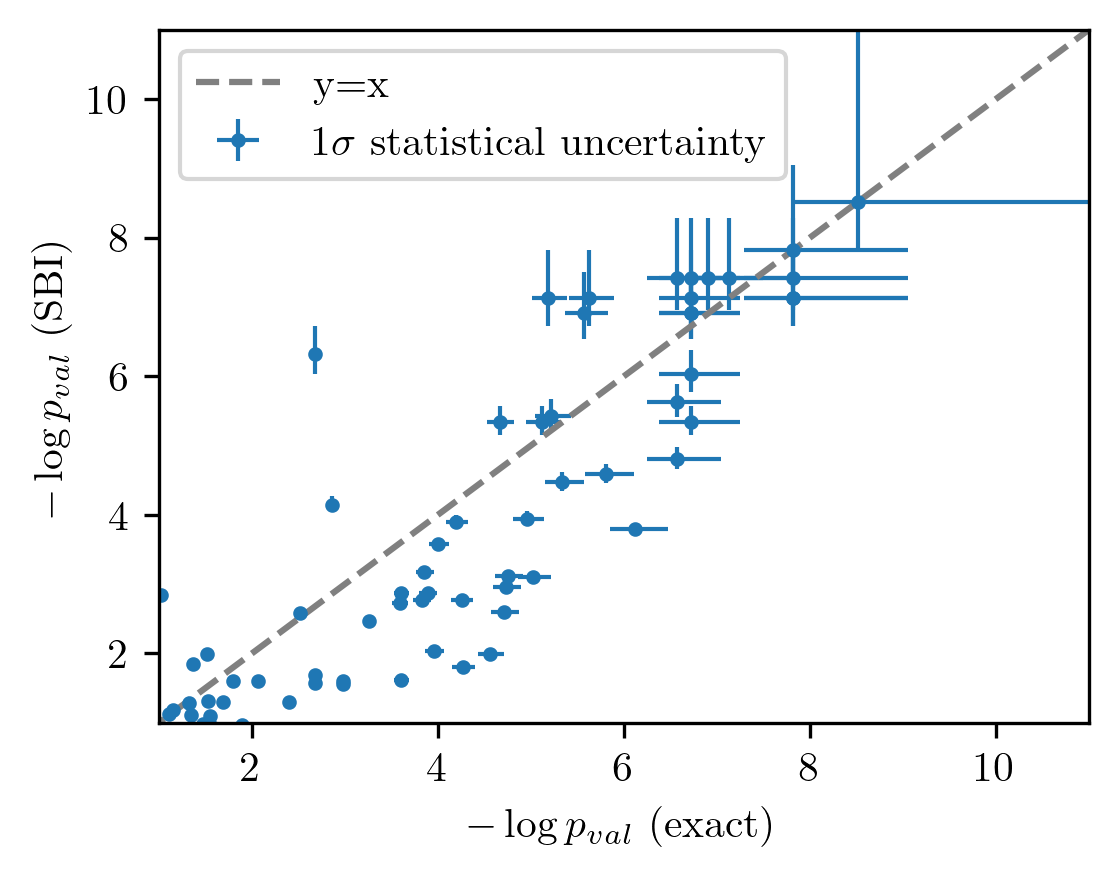

In [192]:
fig, axs = plt.subplots(1,1,figsize=(4,3), dpi=300)
plt.xlim(1,11)
plt.ylim(1,11)
plt.errorbar(
    log_p_vals_exact_freq,
    log_p_vals,
    xerr=[low_err, upp_err],
    yerr=[low_erry, upp_erry],
    fmt='o',
    markersize=2.5,
    elinewidth=1,
    label=r'$1\sigma$ statistical uncertainty')
plt.plot(np.linspace(0,11,10), np.linspace(0,11,10), color = 'grey', linestyle = 'dashed', label = 'y=x')
plt.legend()
plt.xlabel("$-\log p_{val}$ (exact)")
plt.ylabel("$-\log p_{val}$ (SBI)")